<a href="https://colab.research.google.com/github/SEBIN6/Basic-Sales-Summary-from-a-Tiny-SQLite-Database-using-Python/blob/main/task7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

**Create a database,inserting values,displaying the values and a bar chart**

Sales Summary:
  product  total_qty  revenue
0  Laptop          7   7000.0
1   Phone         18   9000.0
2  Tablet          3    900.0


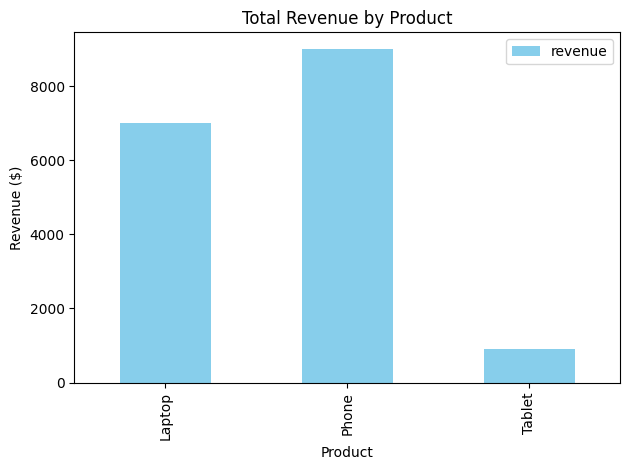

In [53]:
def create_database():
  conn = sqlite3.connect('sales_data.db')
  cursor=conn.cursor()
  cursor.execute("""
        CREATE TABLE IF NOT EXISTS sales (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            product TEXT NOT NULL,
            quantity INTEGER NOT NULL,
            price REAL NOT NULL
        )
    """)
  cursor.execute("DELETE FROM sales")
  sample_data = [
    ("Laptop", 5, 1000.0),
    ("Phone", 10, 500.0),
    ("Tablet", 3, 300.0),
    ("Laptop", 2, 1000.0),
    ("Phone", 8, 500.0)
  ]
  cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)

def analyze_data():
 conn = sqlite3.connect("sales_data.db")
 query = """
        SELECT product,
               SUM(quantity) AS total_qty,
               SUM(quantity * price) AS revenue
        FROM sales
        GROUP BY product
    """
 df = pd.read_sql_query(query, sqlite3.connect('sales_data.db'))
 sqlite3.connect('sales_data.db').close()
 print("Sales Summary:")
 print(df)

 df.plot(kind='bar', x='product', y='revenue', title='Total Revenue by Product', color='skyblue')
 plt.xlabel('Product')
 plt.ylabel('Revenue ($)')
 plt.tight_layout()
 plt.show()

create_database()
analyze_data()